In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


In [2]:
# 1. Load Data
ticker = 'GOOGL'
data = yf.download(ticker, start='2015-01-01', end='2023-12-31')

[*********************100%***********************]  1 of 1 completed


In [4]:
# 2. Preprocess Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1,1))

prediction_days = 60
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [5]:
# 3. Build the LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Prediction of the next closing price

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=10, batch_size=32)

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.0197
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0031
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0028
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0027
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0025
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0024
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0022


In [6]:
# 4. Test the Model
test_data = yf.download(ticker, start='2024-01-01', end='2024-12-31')
actual_prices = test_data['Close'].values

total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.transform(model_inputs)

x_test = []
for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

[*********************100%***********************]  1 of 1 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


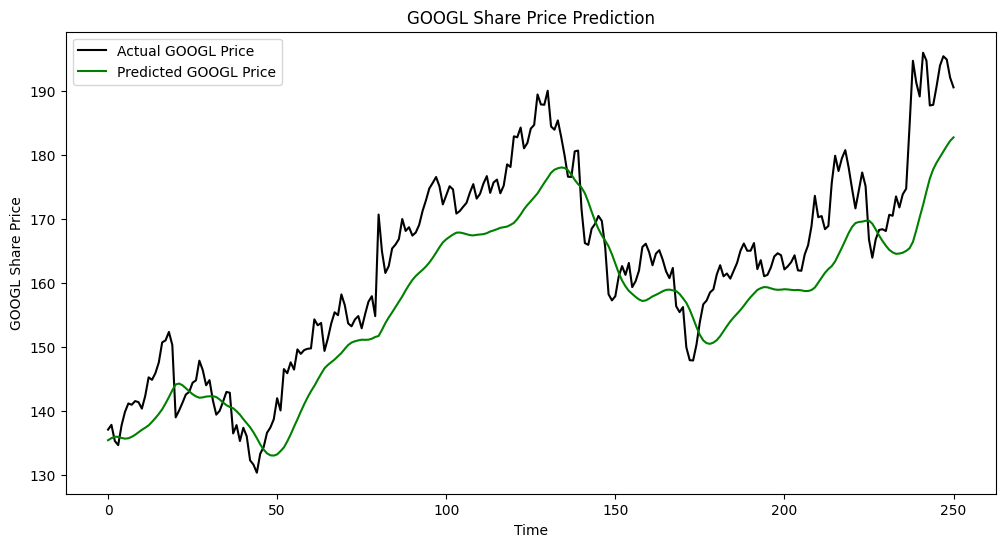

In [7]:
# 5. Output Visualization
plt.figure(figsize=(12,6))
plt.plot(actual_prices, color="black", label=f"Actual {ticker} Price")
plt.plot(predicted_prices, color="green", label=f"Predicted {ticker} Price")
plt.title(f"{ticker} Share Price Prediction")
plt.xlabel("Time")
plt.ylabel(f"{ticker} Share Price")
plt.legend()
plt.show()